In [2]:

import numpy as np
import matplotlib.pyplot as plt

def fibonacci_hemisphere_symmetric(half_samples=10, remove_z1=True, both_sides=True):
    """
    Sample evenly across a hemisphere using fibonacci lattice, and return
    points on both sides of the hemisphere.
    """

    # account for top point
    half_samples += 1

    points = []
    phi = np.pi * (3. - np.sqrt(5.))  # golden angle in radians

    for i in range(half_samples):
        z = 1 - (i / float(half_samples - 1))  # z goes from 1 to 0
        radius = np.sqrt(1 - z * z)  # radius at z

        theta = phi * i  # golden angle increment

        x = np.cos(theta) * radius
        y = np.sin(theta) * radius

        if not np.isclose(z, 1):
            points.append((x, y, z))
            if both_sides:
                points.append((-x, -y, -z))
        elif not remove_z1:
            points.append((x, y, z))
            if both_sides:
                points.append((-x, -y, -z))

    return np.array(points)



In [3]:

# Parameters
Noff_pairs: int = 32 # number of directions
both_sides: bool = False # true samples on both sides of hemisphere

# sample additional directions
diff_tensor = fibonacci_hemisphere_symmetric(Noff_pairs, both_sides=both_sides)



Directions per b-value:
b=1000: 64 directions
b=3000: 64 directions


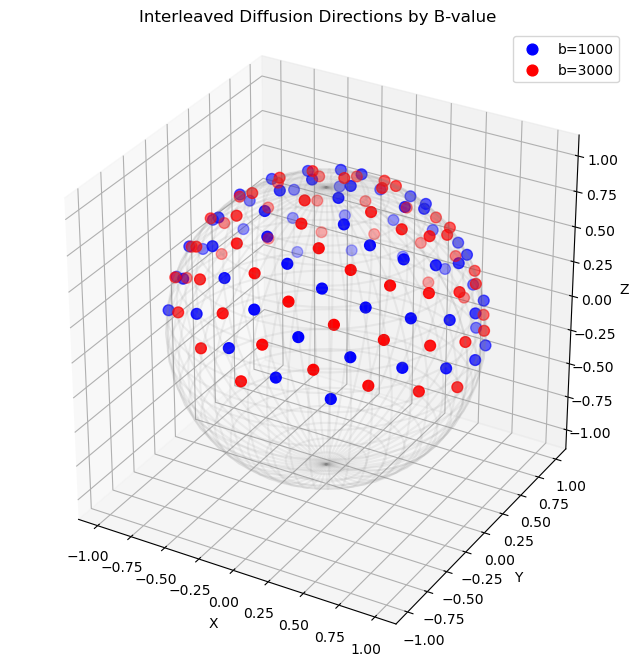

Total directions for b=1000: 65
Total directions for b=3000: 65


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat

# ----------------------------
# Function: Fibonacci lattice
# ----------------------------
def fibonacci_sphere(N, hemisphere=False):
    """
    Generate N points roughly evenly spaced on a sphere.
    If hemisphere=True, only z >= 0
    """
    phi = np.pi * (3. - np.sqrt(5.))  # golden angle
    points = []

    for i in range(N):
        z = 1 - 2*i/(N-1) if not hemisphere else 1 - i/(N-1)
        radius = np.sqrt(1 - z**2)
        theta = phi * i
        x = np.cos(theta) * radius
        y = np.sin(theta) * radius
        points.append([x, y, z])

    return np.array(points)

# ----------------------------
# Function: rotate vectors so v_from -> v_to
# ----------------------------
def rotate_vector_from_to(vectors, v_from, v_to):
    """
    Rotate all vectors so that v_from maps to v_to.
    vectors : Nx3 array
    v_from  : 3-element vector to rotate from
    v_to    : 3-element vector to rotate to
    """
    v_from = v_from / np.linalg.norm(v_from)
    v_to = v_to / np.linalg.norm(v_to)

    # Cross product and dot product
    v = np.cross(v_from, v_to)
    c = np.dot(v_from, v_to)
    s = np.linalg.norm(v)

    if s == 0:
        # vectors are parallel, no rotation needed
        return vectors

    # Rodrigues' rotation formula
    vx = np.array([[    0, -v[2],  v[1]],
                   [ v[2],     0, -v[0]],
                   [-v[1],  v[0],    0]])
    R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s**2))

    return vectors @ R.T

# ----------------------------
# Parameters
# ----------------------------
N_total = 128        # total directions
bvalues = [1000, 3000]
hemisphere = True

# Generate directions
all_dirs = fibonacci_sphere(N_total, hemisphere=hemisphere)

# ----------------------------
# Rotate directions 
# ----------------------------
middle_dir = np.array([0.1,0.1,0.9])#np.array([0.1,0.1,90])  # desired middle direction
middle_dir = middle_dir / np.linalg.norm(middle_dir)  # normalize

# Make sure only 4 decimal places but still normalized
middle_dir = np.round(middle_dir, 4)
middle_dir = middle_dir / np.linalg.norm(middle_dir)

all_dirs = rotate_vector_from_to(all_dirs, np.array([0,0,1]), middle_dir)

# ----------------------------
# Interleave directions across b-values
# ----------------------------
dirs_bval = {bval: [] for bval in bvalues}

for i, dir_vec in enumerate(all_dirs):
    bval = bvalues[i % len(bvalues)]
    dirs_bval[bval].append(dir_vec)

# Convert lists to arrays
for bval in bvalues:
    dirs_bval[bval] = np.array(dirs_bval[bval])

print("Directions per b-value:")
for bval, dirs in dirs_bval.items():
    print(f"b={bval}: {len(dirs)} directions")

# ----------------------------
# Plot
# ----------------------------
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
colors = {1000: 'blue', 3000: 'red'}

for bval, dirs in dirs_bval.items():
    ax.scatter(dirs[:,0], dirs[:,1], dirs[:,2], label=f'b={bval}', s=60, color=colors[bval])

# Optional: wireframe for reference
u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax.plot_wireframe(x, y, z, color='gray', alpha=0.1)

ax.set_box_aspect([1,1,1])
ax.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Interleaved Diffusion Directions by B-value')
plt.show()




# ----------------------------
# Prepend b0 direction [0, 0, 0]
# ----------------------------
b0 = np.array([[0.0, 0.0, 0.0]])

dirs_bval[1000] = np.vstack((b0, dirs_bval[1000]))
dirs_bval[3000] = np.vstack((b0, dirs_bval[3000]))

# print number of dirs
print(f"Total directions for b=1000: {len(dirs_bval[1000])}")
print(f"Total directions for b=3000: {len(dirs_bval[3000])}")

# ----------------------------
# Save to  .mat file
# ----------------------------
savemat("diffusion_directions_DTI.mat", {
    "b1000": dirs_bval[1000],
    "b3000": dirs_bval[3000]
})

In [5]:
middle_dir

array([0.10979679, 0.10979679, 0.98787111])

Directions per b-value:
b=1000: 32
b=3000: 32


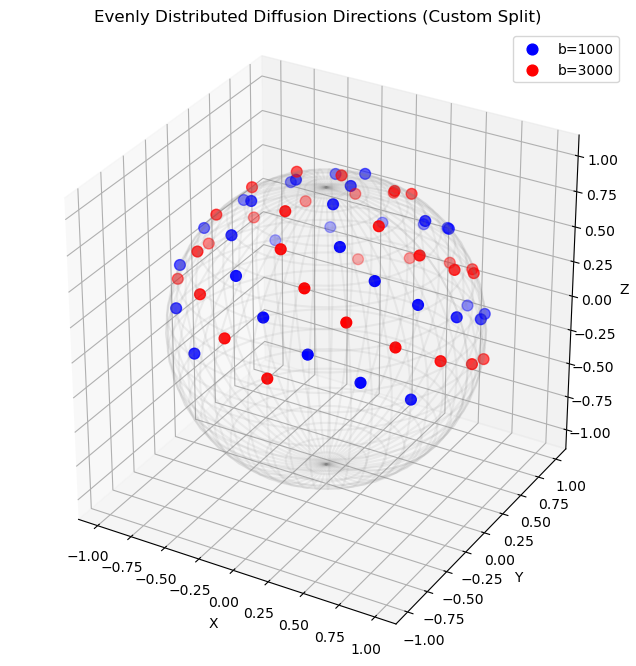

Total directions for b=1000: 33
Total directions for b=3000: 33


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat

# ============================================================
# Function: Fibonacci lattice
# ============================================================
def fibonacci_sphere(N, hemisphere=False):
    phi = np.pi * (3. - np.sqrt(5.))
    points = []

    for i in range(N):
        z = 1 - 2*i/(N-1) if not hemisphere else 1 - i/(N-1)
        r = np.sqrt(1 - z**2)
        theta = phi * i
        x = np.cos(theta) * r
        y = np.sin(theta) * r
        points.append([x, y, z])

    return np.array(points)

# ============================================================
# Function: rotate vectors so v_from -> v_to
# ============================================================
def rotate_vector_from_to(vectors, v_from, v_to):
    v_from = v_from / np.linalg.norm(v_from)
    v_to   = v_to   / np.linalg.norm(v_to)

    v = np.cross(v_from, v_to)
    c = np.dot(v_from, v_to)
    s = np.linalg.norm(v)

    if s == 0:
        return vectors

    vx = np.array([[    0, -v[2],  v[1]],
                   [ v[2],     0, -v[0]],
                   [-v[1],  v[0],    0]])

    R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s**2))
    return vectors @ R.T

# ============================================================
# Parameters
# ============================================================
N_total    = 128-32-32
bvalues    = [1000, 3000]
hemisphere = True

# Desired split (EXACT)
split_counts = {
    1000: 32,
    3000: 32
}
assert sum(split_counts.values()) == N_total

# ============================================================
# Generate and rotate directions
# ============================================================
all_dirs = fibonacci_sphere(N_total, hemisphere=hemisphere)

middle_dir = np.array([0.1, 0.1, 0.9])
middle_dir = middle_dir / np.linalg.norm(middle_dir)
middle_dir = np.round(middle_dir, 4)
middle_dir = middle_dir / np.linalg.norm(middle_dir)

all_dirs = rotate_vector_from_to(all_dirs, np.array([0, 0, 1]), middle_dir)

# ============================================================
# EVENLY DISTRIBUTED assignment with quota tracking
# ============================================================
dirs_bval = {b: [] for b in bvalues}
assigned  = {b: 0 for b in bvalues}

for d in all_dirs:
    # Find b-value most behind its quota
    deficits = {
        b: assigned[b] / split_counts[b]
        for b in bvalues
        if assigned[b] < split_counts[b]
    }

    b_assign = min(deficits, key=deficits.get)

    dirs_bval[b_assign].append(d)
    assigned[b_assign] += 1

# Convert to arrays
for b in bvalues:
    dirs_bval[b] = np.array(dirs_bval[b])

# ============================================================
# Report
# ============================================================
print("Directions per b-value:")
for b in bvalues:
    print(f"b={b}: {len(dirs_bval[b])}")

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {1000: 'blue', 3000: 'red'}

for bval, dirs in dirs_bval.items():
    ax.scatter(dirs[:,0], dirs[:,1], dirs[:,2],
               label=f'b={bval}', s=60, color=colors[bval])

# Reference sphere
u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
ax.plot_wireframe(np.cos(u)*np.sin(v),
                  np.sin(u)*np.sin(v),
                  np.cos(v),
                  color='gray', alpha=0.1)

ax.set_box_aspect([1, 1, 1])
ax.legend()
ax.set_title('Evenly Distributed Diffusion Directions (Custom Split)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

# ============================================================
# Prepend b0
# ============================================================
b0 = np.array([[0.0, 0.0, 0.0]])
for b in bvalues:
    dirs_bval[b] = np.vstack((b0, dirs_bval[b]))
    print(f"Total directions for b={b}: {len(dirs_bval[b])}")

# ============================================================
# Save
# ============================================================
savemat("diffusion_directions_DTI.mat", {
    "b1000": dirs_bval[1000],
    "b3000": dirs_bval[3000]
})

In [7]:
dirs_bval[3000]

array([[ 0.        ,  0.        ,  0.        ],
       [-0.02273711,  0.22799694,  0.97339633],
       [ 0.28749535,  0.34395318,  0.89389185],
       [ 0.4297786 , -0.10919601,  0.89630719],
       [-0.10980881, -0.30521717,  0.9459305 ],
       [-0.38030373,  0.29233863,  0.87744356],
       [ 0.25529609,  0.6250107 ,  0.73768932],
       [ 0.67851285, -0.04630052,  0.73312794],
       [ 0.00481981, -0.55426374,  0.83232715],
       [-0.59855605,  0.11236958,  0.7931606 ],
       [ 0.0394893 ,  0.78747962,  0.61507434],
       [ 0.80681483,  0.16750628,  0.56656109],
       [ 0.24282127, -0.68048444,  0.69136008],
       [-0.68757149, -0.17011631,  0.70590785],
       [-0.25675032,  0.81710072,  0.5161644 ],
       [ 0.79757409,  0.44402406,  0.40831141],
       [ 0.52321313, -0.66720366,  0.53017666],
       [-0.63546269, -0.47865826,  0.60586586],
       [-0.55982378,  0.70607989,  0.43364563],
       [ 0.64950873,  0.71214926,  0.26642417],
       [ 0.77724538, -0.51822237,  0.356